In [19]:
import numpy as np, pandas as pd, tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/가천대학교/2026-1/인공지능개론/Colab Notebooks/2. 데이터/TSLA.csv')
data = df.drop(['Date'], axis=1)
data




,Open,High,Low,Close,Adj Close,Volume
0,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...
2951,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


In [36]:
# 2. 정규화
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data)


In [35]:
# 훈련 데이터, 테스트 데이터 분리
Test_Size=200
train_data = data[:-Test_Size]
test_data = data[-Test_Size:]


In [27]:
# 순차 훈련 데이터
def make_sample(data, window):
  train=[]
  target=[]
  for i in range(len(data)-window):
    train.append(data[i:i+window])
    target.append(data[i+window])
  return np.array(train), np.array(target)

X_train,y_train=make_sample(train_data,30)
X_test,y_test=make_sample(test_data,30)

In [44]:
# 시퀀스 생성
window = 12   # 최근 12개월 → 다음달 예측
X, y = [], []
for i in range(len(data)-window):
    X.append(data[i:i+window])
    y.append(data[i+window])
X, y = np.array(X), np.array(y)

In [46]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(64, return_sequences=True, input_shape=(window,1)),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

In [47]:
# 모델 학습
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(X_train, y_train,epochs=100,batch_size=16)

Epoch 1/100


ValueError: Exception encountered when calling SimpleRNNCell.call().

[1mDimensions must be equal, but are 6 and 1 for '{{node sequential_6_1/simple_rnn_1/simple_rnn_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_6_1/simple_rnn_1/strided_slice_2, sequential_6_1/simple_rnn_1/simple_rnn_cell_1/Cast/ReadVariableOp)' with input shapes: [?,6], [1,64].[0m

Arguments received by SimpleRNNCell.call():
  • sequence=tf.Tensor(shape=(None, 6), dtype=float32)
  • states=('tf.Tensor(shape=(None, 64), dtype=float32)',)
  • training=True

In [37]:
# 만들어둔 테스트 셋으로 주가 예측
pred = model.predict(X_test)
print(y_test.shape)
print(pred.shape)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
(170, 6)
(170, 30, 1)


ValueError: x and y can be no greater than 2D, but have shapes (170,) and (170, 30, 1)

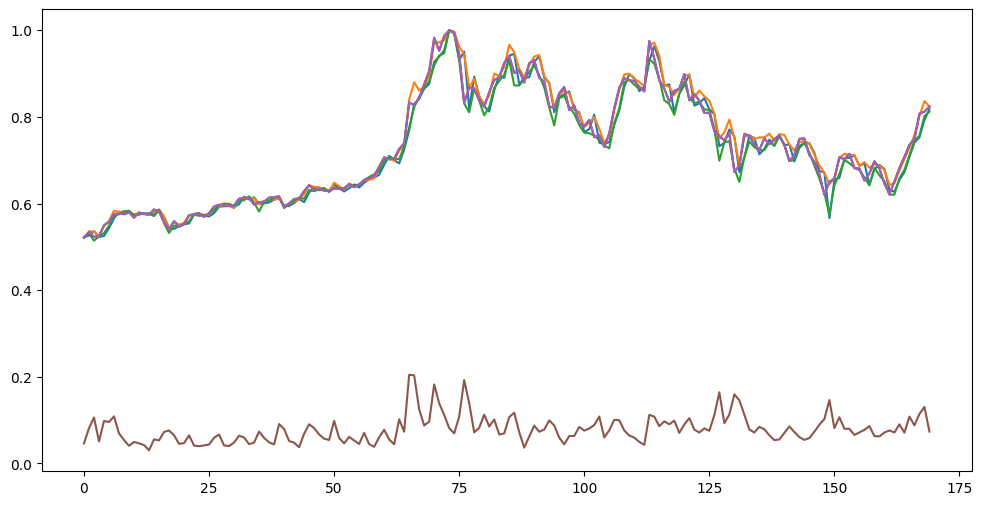

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='stock')
plt.plot(pred, label='Predicted')
plt.legend()
plt.title("TSLA Stock Price Prediction")
plt.show()